# Image Classification

## Import

In [ ]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import ToTensor,Compose,RandomHorizontalFlip, Normalize, ToPILImage, RandomRotation, ColorJitter
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import torchvision
import torch.optim.lr_scheduler as lr_scheduler

from tools.plot import show_images, plot_metrics
from models.mlp_with_reg import MLP

seed = 1
random.seed(seed)  # Python 内置随机数种子
np.random.seed(seed)  # NumPy 随机种子
torch.manual_seed(seed)  # PyTorch 随机种子
torch.cuda.manual_seed(seed)  # 设置 CUDA 的随机种子
torch.cuda.manual_seed_all(seed)  # 如果有多个 GPU 也要设置
torch.backends.cudnn.deterministic = True  # 让 CNN 结果可复现
torch.backends.cudnn.benchmark = False  # 关闭自动优化

# dataset config

batch_size = 128

# TODO: 定义数据集的预处理步骤，在 transforms.ToTensor() 之前添加数据增强方法
transform = transforms.Compose([
    # TODO 1: 随机水平翻转，设置翻转概率（通常设置为 0.2 或 0.5）
    # transforms.RandomHorizontalFlip(p=?)
    
    # TODO 2: 随机裁剪，填充一定像素后裁剪回原始大小（通常填充 4 像素）
    # transforms.RandomCrop(?, padding=?)
    
    # TODO 3: 颜色抖动，调整亮度、对比度、饱和度、色相（可尝试 0.2, 0.2, 0.2, 0.1）
    # transforms.ColorJitter(brightness=?, contrast=?, saturation=?, hue=?)
    
    # TODO 4: 旋转图片，随机旋转一定角度（可尝试 ±15 度）
    # transforms.RandomRotation(?)
    
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


subset_size = 20000
trainset = torchvision.datasets.CIFAR10(root='/data', train=True, download=True, transform=transform)
trainset = torch.utils.data.Subset(trainset, range(subset_size))
testset = torchvision.datasets.CIFAR10(root='/data', train=True, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

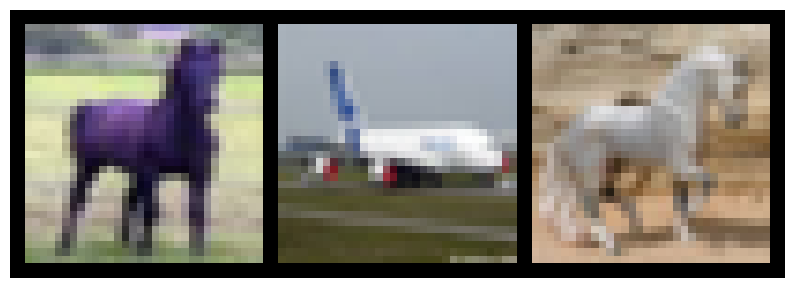

In [2]:
show_images(trainloader, num_images=3)

## Training Loop

In [3]:
# 训练一个batch的函数
def train_one_batch(model, inputs, labels, optimizer, criterion, device):

    inputs, labels = inputs.to(device), labels.to(device)
    
    optimizer.zero_grad()
    
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    
    loss.backward()
    optimizer.step()
    
    return loss, outputs

# Evaluation

In [4]:
# 测试函数
def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(test_loader)
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


## Main Loop

In [5]:
# 超参数
num_epochs = 20
learning_rate = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP().to(device)


criterion = nn.CrossEntropyLoss()


# TODO: 在优化器中添加 L2 正则化（权重衰减值可尝试0.01）
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# 记录训练过程中的指标
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
learning_rates = []

# 训练循环
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_correct = 0
    total_samples = 0
    
    # 按batch训练
    for i, batch_data in enumerate(trainloader):
        inputs, labels = batch_data
        inputs, labels = inputs.to(device), labels.to(device)
        batch_loss, batch_output = train_one_batch(model, inputs, labels, optimizer, criterion, device)
        epoch_loss += batch_loss.item()
        
        _, batch_prediction = torch.max(batch_output.data, 1)
        batch_size = labels.size(0)
        total_samples += batch_size
        epoch_correct += (batch_prediction == labels).sum().item()
            
    avg_train_loss = epoch_loss / len(trainloader)
    avg_train_acc = epoch_correct / total_samples
    
    # 测试
    test_loss, test_acc = evaluate(model, testloader, criterion, device)
    
    # 记录指标
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    learning_rates.append(scheduler.get_last_lr()[0])  # 记录当前学习率

    scheduler.step()
    
    # 打印训练状态
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    print(f'Current Learning Rate: {scheduler.get_last_lr()[0]:.6f}')  # 打印当前学习率

Epoch [1/20]
Train Loss: 1.7749, Train Acc: 0.3644
Test Loss: 1.6805, Test Acc: 0.3936
Current Learning Rate: 0.001000
Epoch [2/20]
Train Loss: 1.5480, Train Acc: 0.4489
Test Loss: 1.5548, Test Acc: 0.4505
Current Learning Rate: 0.001000
Epoch [3/20]
Train Loss: 1.4036, Train Acc: 0.4985
Test Loss: 1.5184, Test Acc: 0.4638
Current Learning Rate: 0.001000
Epoch [4/20]
Train Loss: 1.2880, Train Acc: 0.5404
Test Loss: 1.4888, Test Acc: 0.4795
Current Learning Rate: 0.001000
Epoch [5/20]
Train Loss: 1.1691, Train Acc: 0.5819
Test Loss: 1.4896, Test Acc: 0.4855
Current Learning Rate: 0.000500
Epoch [6/20]
Train Loss: 0.9172, Train Acc: 0.6684
Test Loss: 1.4842, Test Acc: 0.5176
Current Learning Rate: 0.000500
Epoch [7/20]
Train Loss: 0.7723, Train Acc: 0.7200
Test Loss: 1.5969, Test Acc: 0.5085
Current Learning Rate: 0.000500
Epoch [8/20]
Train Loss: 0.6401, Train Acc: 0.7694
Test Loss: 1.7416, Test Acc: 0.5083
Current Learning Rate: 0.000500
Epoch [9/20]
Train Loss: 0.5161, Train Acc: 0.81

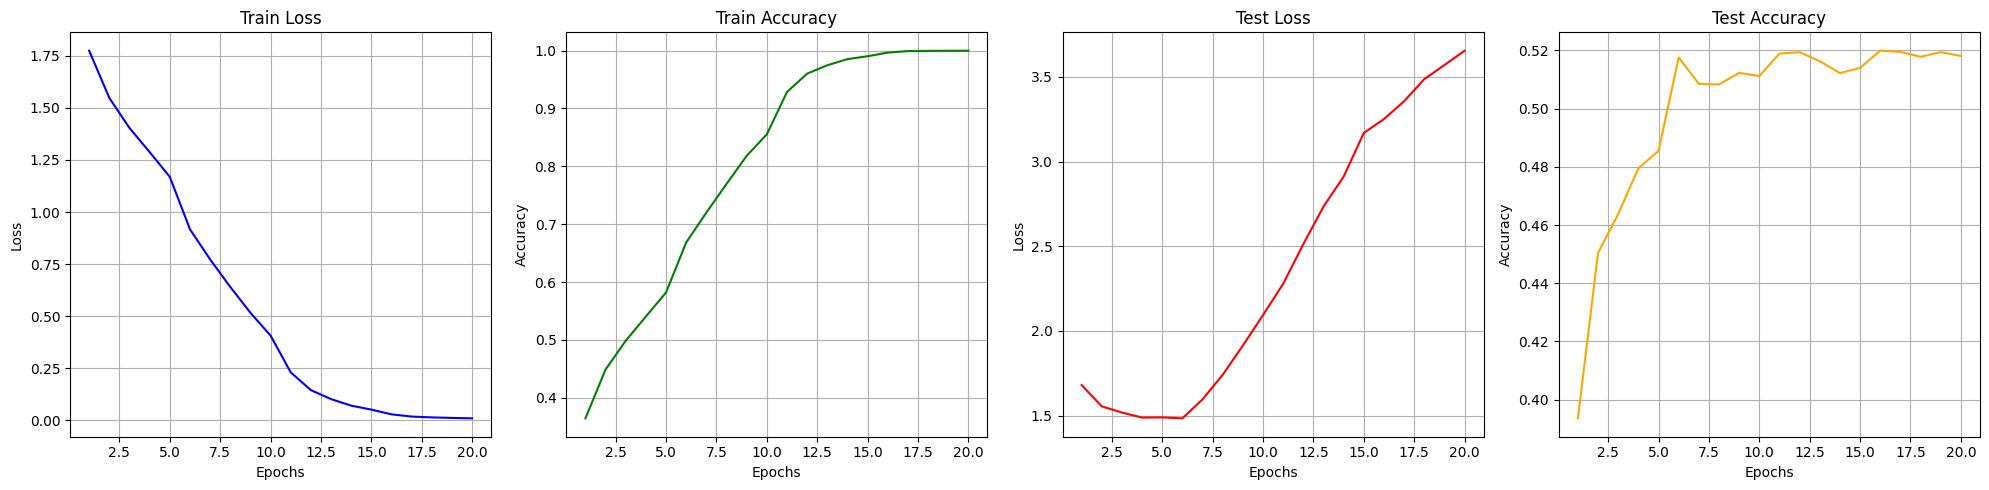

In [6]:
plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies)